# 05. Hypothesis Testing Beyond p-Values

Notebook 04 showed that interval procedures are better understood as behavioral objects than as mechanical formulas. We take the same approach to hypothesis testing. The goal is not to discard tests. The goal is to use them without collapsing inference into a ritual about whether a number fell just above or below 0.05.

Hypothesis tests can be useful evidence summaries. They can compare the observed data with what would be expected under a null model, and they can be paired with likelihood, intervals, and decision thresholds. But they become misleading when we ask them to do jobs they were never designed to do: certify that the null is true, certify that an effect is important, or convert a complicated decision into a binary label.

We will work through one central operational question: can leadership justify advertising a premium enterprise support promise only if the enterprise SLA breach rate is below 15%? Using the same audited support data as the previous notebooks, we will compare Wald, score, and likelihood-ratio tests, show how fragile threshold-crossing can be, and then push beyond p-values by adding effect size, interval evidence, and practical decision criteria.

## Learning Objectives

After working through this lecture, you should be able to:

1. State what a null hypothesis, alternative hypothesis, test statistic, and p-value mean.
2. Distinguish Wald, score, and likelihood-ratio tests for a one-sample binomial threshold problem.
3. Explain why a p-value is not the probability that the null hypothesis is true.
4. Show how tiny data changes can flip a "significant / non-significant" label even when the underlying evidence barely changes.
5. Demonstrate that p-values vary substantially across repeated samples, especially when the true effect is near the null.
6. Explain why a small p-value does not guarantee practical importance.
7. Use tests together with effect sizes and intervals to write a more defensible decision memo.

### Dataset and Experiment Design

The dataset is the audited enterprise-support setting from the earlier inference notebooks. Each row is a ticket, and the primary binary outcome is whether the ticket breached the SLA. The business threshold is explicit: leadership is comfortable advertising the premium support promise only if the underlying enterprise breach rate is below 15%.

The experiment evaluates that threshold using several testing frameworks. Wald, score, and likelihood-ratio tests all compare the observed audit with a null boundary, but they communicate evidence through different approximations. The notebook then pairs the tests with effect sizes and intervals so the result is not reduced to a pass/fail label.

This setup is intentionally threshold-driven. The practical question is not whether the breach rate is exactly zero or whether a p-value is below 0.05. The question is whether the evidence is strong enough, precise enough, and operationally meaningful enough to support a service promise.

In [1]:
# Load the libraries and notebook settings used in the examples below.
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'notebooks' / '_shared' / 'display.py').exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

from notebooks._shared.display import smart_display

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f"{x:0.3f}")
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 160)
np.random.seed(2026)


def make_support_population(n=60_000, seed=310, sla_minutes=60):
    """
    Construct the support population object used in this lecture.
    
    Parameters:
        n: Number of observations, rows, or simulated units to generate.
        seed: Random seed used to make the simulation or resampling reproducible.
        sla_minutes: Decision or statistical threshold used to define the target, interval, or rule.
    
    Returns:
        A pandas DataFrame representing the simulated support population, including covariates, operational outcomes, and ground-truth targets used later for inference checks.
    
    Idea:
        Create a known synthetic population so sample estimates, intervals, likelihoods, and inference procedures can be checked against ground truth.
    """
    rng = np.random.default_rng(seed)

    seller_tier = rng.choice(['growth', 'enterprise'], size=n, p=[0.72, 0.28])
    severity = rng.choice(['routine', 'complex', 'urgent'], size=n, p=[0.55, 0.32, 0.13])
    region = rng.choice(['North', 'South', 'West', 'Central'], size=n, p=[0.24, 0.22, 0.29, 0.25])
    channel = rng.choice(['chat', 'email', 'phone'], size=n, p=[0.44, 0.31, 0.25])

    queue_pressure = np.clip(
        rng.normal(0.0, 0.85, n)
        + np.where(region == 'West', 0.18, 0.0)
        + np.where(region == 'South', 0.08, 0.0),
        -1.5,
        2.8,
    )
    analyst_tenure_years = rng.gamma(shape=3.5, scale=1.3, size=n)
    automation_assist = rng.binomial(
        1,
        p=np.where(severity == 'routine', 0.72, np.where(severity == 'complex', 0.48, 0.22)),
        size=n,
    )

    severity_base = {'routine': 30, 'complex': 48, 'urgent': 70}
    tier_effect = {'growth': -2, 'enterprise': 4}
    channel_effect = {'chat': -5, 'email': 2, 'phone': 7}
    region_effect = {'North': -2, 'South': 2, 'West': 4, 'Central': 0}

    service_noise = rng.normal(0, 7, n) + rng.gamma(2.3, 2.6, n)

    resolution_minutes = (
        np.vectorize(severity_base.get)(severity)
        + np.vectorize(tier_effect.get)(seller_tier)
        + np.vectorize(channel_effect.get)(channel)
        + np.vectorize(region_effect.get)(region)
        + 5.8 * queue_pressure
        - 1.8 * analyst_tenure_years
        - 6.0 * automation_assist
        + service_noise
    )
    resolution_minutes = np.clip(resolution_minutes, 5, None)

    sla_breach = (resolution_minutes > sla_minutes).astype(int)
    critical_failure = (resolution_minutes > 90).astype(int)
    cost_per_ticket = 14 + 0.72 * resolution_minutes + 18 * sla_breach + 0.12 * np.maximum(resolution_minutes - sla_minutes, 0) ** 1.1

    return pd.DataFrame(
        {
            'seller_tier': seller_tier,
            'severity': severity,
            'region': region,
            'channel': channel,
            'queue_pressure': queue_pressure,
            'analyst_tenure_years': analyst_tenure_years,
            'automation_assist': automation_assist,
            'resolution_minutes': resolution_minutes,
            'sla_breach': sla_breach,
            'critical_failure': critical_failure,
            'cost_per_ticket': cost_per_ticket,
        }
    )


def normal_cdf(z):
    """
    Evaluate the normal cumulative distribution function at the supplied values.
    
    Parameters:
        z: Normal critical value or z-score used in the interval or tail-probability calculation.
    
    Returns:
        The standard-normal cumulative probability for `z`, returned as a scalar when `z` is scalar and as an array otherwise.
    
    Idea:
        Evaluate lower-tail normal probabilities so p-values and operating characteristics can be computed from a reference distribution.
    """
    z_arr = np.asarray(z)
    erf_vec = np.vectorize(math.erf)
    values = 0.5 * (1 + erf_vec(z_arr / np.sqrt(2)))
    return values.item() if np.isscalar(z) else values


def normal_sf(z):
    """
    Evaluate the normal survival probability at the supplied values.
    
    Parameters:
        z: Normal critical value or z-score used in the interval or tail-probability calculation.
    
    Returns:
        The upper-tail standard-normal probability for `z`.
    
    Idea:
        Evaluate upper-tail normal probabilities so one-sided evidence calculations remain numerically stable and readable.
    """
    return 1 - normal_cdf(z)


def one_sample_binomial_tests(x, n, p0, alternative='greater'):
    """
    Compare Wald, score, and signed likelihood-ratio tests for a binomial threshold.
    
    Parameters:
        x: Number of observed events, such as enterprise tickets that breached the SLA.
        n: Number of Bernoulli trials or audited units used to estimate the event rate.
        p0: Null-hypothesis event probability to test against the observed rate.
        alternative: Direction of the alternative hypothesis. Use "greater", "less", or "two-sided".
    
    Returns:
        A pandas DataFrame with one row per test family, including the test statistic and p-value.
    
    Idea:
        Hold the business threshold fixed and show how several large-sample tests can give similar but not identical evidence summaries.
    """
    p_hat = x / n
    p_hat_safe = np.clip(p_hat, 1e-12, 1 - 1e-12)
    p0_safe = np.clip(p0, 1e-12, 1 - 1e-12)

    wald_z = (p_hat - p0) / np.sqrt(max(p_hat * (1 - p_hat) / n, 1e-12))
    score_z = (p_hat - p0) / np.sqrt(p0 * (1 - p0) / n)

    ll_hat = x * np.log(p_hat_safe) + (n - x) * np.log(1 - p_hat_safe)
    ll_0 = x * np.log(p0_safe) + (n - x) * np.log(1 - p0_safe)
    lr_stat = 2 * (ll_hat - ll_0)
    signed_root_lr = np.sign(p_hat - p0) * np.sqrt(max(lr_stat, 0))

    if alternative == 'greater':
        wald_p = normal_sf(wald_z)
        score_p = normal_sf(score_z)
        lr_p = normal_sf(signed_root_lr)
    elif alternative == 'less':
        wald_p = normal_cdf(wald_z)
        score_p = normal_cdf(score_z)
        lr_p = normal_cdf(signed_root_lr)
    else:
        wald_p = 2 * normal_sf(abs(wald_z))
        score_p = 2 * normal_sf(abs(score_z))
        lr_p = 2 * normal_sf(abs(signed_root_lr))

    return pd.DataFrame(
        [
            {'test': 'Wald', 'statistic': wald_z, 'p_value': wald_p},
            {'test': 'Score', 'statistic': score_z, 'p_value': score_p},
            {'test': 'Likelihood-ratio', 'statistic': signed_root_lr, 'p_value': lr_p},
        ]
    )


def profile_likelihood_interval_proportion(x, n, upper=0.35, num=5000):
    """
    Invert the binomial likelihood-ratio statistic to form a proportion interval.
    
    Parameters:
        x: Number of observed events in the binomial sample.
        n: Number of Bernoulli trials or audited units.
        upper: Upper edge of the probability grid searched for likelihood-supported values.
        num: Number of grid points used to approximate the likelihood interval.
    
    Returns:
        A tuple containing the lower and upper endpoints of the profile-likelihood interval for the event probability.
    
    Idea:
        Use likelihood geometry to show which threshold values remain compatible with the observed event count.
    """
    p_grid = np.linspace(1e-6, upper, num)
    loglik = x * np.log(np.clip(p_grid, 1e-12, 1 - 1e-12)) + (n - x) * np.log(np.clip(1 - p_grid, 1e-12, 1 - 1e-12))
    mask = 2 * (loglik.max() - loglik) <= 3.841458820694124
    return p_grid[mask][0], p_grid[mask][-1]


def two_sample_mean_test(x_treat, x_control):
    """
    Estimate and test a two-group mean difference.
    
    Parameters:
        x_treat: Outcome values for the treated, assisted, or exposed group.
        x_control: Outcome values for the baseline or comparison group.
    
    Returns:
        A tuple containing the mean difference, standard error, z statistic, two-sided p-value, and 95% confidence interval.
    
    Idea:
        Separate statistical detectability from practical importance by pairing a p-value with the estimated effect size and interval.
    """
    x_treat = np.asarray(x_treat)
    x_control = np.asarray(x_control)
    diff = x_treat.mean() - x_control.mean()
    se = np.sqrt(x_treat.var(ddof=1) / len(x_treat) + x_control.var(ddof=1) / len(x_control))
    z = diff / se
    p_value = 2 * normal_sf(abs(z))
    ci = (diff - 1.96 * se, diff + 1.96 * se)
    return diff, se, z, p_value, ci

## 1. What a Hypothesis Test Does and Does Not Do

A hypothesis test compares the observed data with what would be expected if a null model were correct. The generic structure is:

- null hypothesis $H_0$,
- alternative hypothesis $H_1$,
- test statistic $T(Y)$,
- p-value: the probability, under $H_0$, of observing a statistic at least as extreme as what we saw.

For a one-sided test in which large statistics favor the alternative,

$$
\text{p-value} = P_{H_0}\{T(Y) \ge T(y_{obs})\}.
$$

Three clarifications matter immediately.

1. A p-value is **not** the probability that $H_0$ is true.
2. A large p-value is **not** evidence that the null model has been proven true.
3. A small p-value is **not** evidence that the effect is practically important.

The literature has been emphatic on these points for years (Greenland et al., 2016; Wasserstein et al., 2019). The goal of this lecture is to make those warnings operational and concrete.

## 2. Setup: Can Leadership Claim Enterprise Breach Risk Is Below 15%?

We return to the enterprise support example. Leadership would like to advertise a premium service promise, but only if the enterprise SLA breach rate is below 15%.

That leads to the one-sided testing problem

$$
H_0: p = 0.15
\qquad \text{versus} \qquad
H_1: p > 0.15,
$$

where $p$ is the enterprise-ticket breach rate. This is a deliberately realistic formulation. The question is not whether $p$ differs from zero. The question is whether the operational risk exceeds a policy threshold that matters for service commitments.

In [2]:
# Build a summary table that supports the interpretation in the surrounding notes.
sla_minutes = 60
population = make_support_population(n=60_000, seed=310, sla_minutes=sla_minutes)
audit_sample = population.sample(n=1_000, random_state=2026).reset_index(drop=True)
enterprise_audit = audit_sample.query("seller_tier == 'enterprise'").reset_index(drop=True)

x_enterprise = int(enterprise_audit['sla_breach'].sum())
n_enterprise = len(enterprise_audit)
p_hat_enterprise = x_enterprise / n_enterprise
p0 = 0.15
enterprise_truth = population.query("seller_tier == 'enterprise'")['sla_breach'].mean()
profile_interval = profile_likelihood_interval_proportion(x_enterprise, n_enterprise, upper=0.35)

setup_table = pd.DataFrame(
    [
        {
            'quantity': 'Enterprise tickets audited',
            'value': f"{n_enterprise}",
            'why_it_matters': 'The effective sample size determines how much evidence the test can accumulate.',
        },
        {
            'quantity': 'Observed enterprise breaches',
            'value': f"{x_enterprise}",
            'why_it_matters': 'The test statistics are ultimately driven by the count of breaches and non-breaches.',
        },
        {
            'quantity': 'Observed enterprise breach rate',
            'value': f"{100 * p_hat_enterprise:0.2f}%",
            'why_it_matters': 'This is the effect estimate that should accompany any p-value summary.',
        },
        {
            'quantity': 'Leadership threshold under the null',
            'value': f"{100 * p0:0.1f}%",
            'why_it_matters': 'The null model is a business threshold, not an arbitrary mathematical benchmark.',
        },
        {
            'quantity': 'Approximate 95% profile-likelihood interval',
            'value': f"[{100 * profile_interval[0]:0.2f}%, {100 * profile_interval[1]:0.2f}%]",
            'why_it_matters': 'Interval evidence helps show what values remain reasonably compatible with the data.',
        },
    ]
)
smart_display(setup_table)

,quantity,value,why_it_matters
0,Enterprise tickets audited,294,The effective sample size determines how much evidence the test can accumulate.
1,Observed enterprise breaches,54,The test statistics are ultimately driven by the count of breaches and non-breaches.
2,Observed enterprise breach rate,18.37%,This is the effect estimate that should accompany any p-value summary.
3,Leadership threshold under the null,15.0%,"The null model is a business threshold, not an arbitrary mathematical benchmark."
4,Approximate 95% profile-likelihood interval,"[14.23%, 23.06%]",Interval evidence helps show what values remain reasonably compatible with the data.


Notice what the setup already tells us before any test is run. The observed estimate is 18.37%, which is above the threshold. So the relevant question is not whether the estimate is above 15%; it plainly is. The testing question is whether the sample gives enough evidence to say that a breach rate above 15% is decisively favored over the threshold itself.

That distinction is central. Testing is about evidence strength relative to a null model, not about overwriting the effect estimate.

## 3. Wald, Score, and Likelihood-Ratio Tests for the Same Threshold

For this one-sample binomial problem, the three test families use closely related but not identical logic.

- **Wald test**: standardizes $\hat{p} - p_0$ using an estimated standard error built from $\hat{p}$.
- **Score test**: standardizes $\hat{p} - p_0$ using the standard error implied by the null value $p_0$.
- **Likelihood-ratio test**: compares the maximized binomial likelihood with the likelihood under the null.

In large samples these tests often agree closely, but near a decision threshold they can yield noticeably different p-values. That is not an error. It reflects slightly different approximations applied to the same data.

,test,statistic,p_value,reject_at_5_percent
0,Wald,1.491,0.0680,No
1,Score,1.617,0.0529,No
2,Likelihood-ratio,1.572,0.0580,No


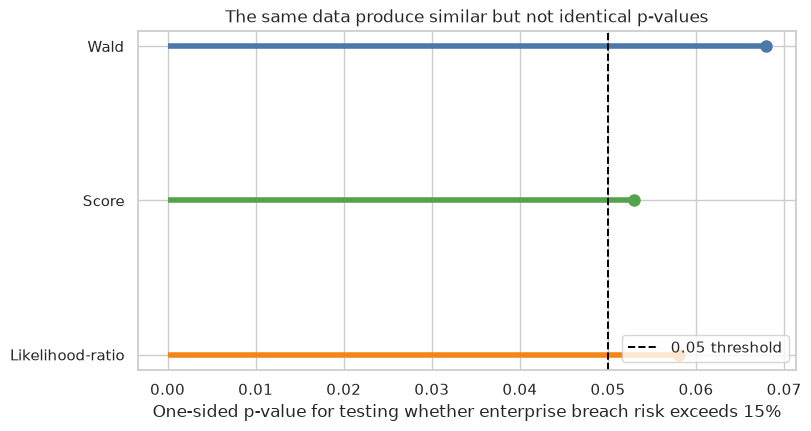

In [3]:
# Compare three test families for the same enterprise breach-threshold question.
enterprise_tests = one_sample_binomial_tests(x_enterprise, n_enterprise, p0=p0, alternative='greater')
enterprise_tests['statistic'] = enterprise_tests['statistic'].map(lambda x: f"{x:0.3f}")
enterprise_tests['p_value'] = enterprise_tests['p_value'].map(lambda x: f"{x:0.4f}")
enterprise_tests['reject_at_5_percent'] = enterprise_tests['p_value'].map(lambda x: 'Yes' if float(x) < 0.05 else 'No')
smart_display(enterprise_tests)

plot_df = one_sample_binomial_tests(x_enterprise, n_enterprise, p0=p0, alternative='greater')
plot_df['color'] = ['#4C78A8', '#54A24B', '#F58518']

fig, ax = plt.subplots(figsize=(8.0, 4.2), constrained_layout=True)
y_positions = np.arange(len(plot_df))[::-1]
for y_pos, (_, row) in zip(y_positions, plot_df.iterrows()):
    ax.hlines(y_pos, 0, row['p_value'], color=row['color'], linewidth=4)
    ax.plot(row['p_value'], y_pos, 'o', color=row['color'], markersize=8)
ax.axvline(0.05, color='black', linestyle='--', linewidth=1.4, label='0.05 threshold')
ax.set_yticks(y_positions)
ax.set_yticklabels(plot_df['test'])
ax.set_xlabel('One-sided p-value for testing whether enterprise breach risk exceeds 15%')
ax.set_title('The same data produce similar but not identical p-values')
ax.legend(loc='lower right')
plt.show()

All three tests land in the same neighborhood, but none crosses below 0.05 for this one-sided threshold test. The score test comes closest, the Wald test is slightly more conservative here, and the likelihood-ratio test sits between them.

The substantive lesson is more important than the ranking:

- the evidence is suggestive that the true breach rate may exceed 15%,
- but it is not overwhelming,
- and a binary "reject / do not reject" label hides how close the result is to the threshold.

This is one reason Greenland et al. (2016) caution against treating a p-value cutoff as a sharp epistemic boundary. The evidence changes smoothly; the label changes abruptly.

## 4. Threshold Fragility: One More Breach Can Flip the Label

A useful way to see the arbitrariness of hard thresholds is to ask what happens if the same audit had produced one fewer or one more breach.

The underlying evidence would barely change. But the p-value can shift enough to move the result from "non-significant" to "significant." That is exactly why threshold language should be handled with care.

,breaches,Wald,Score,Likelihood-ratio
0,53,0.0885,0.0730,0.0783
1,54,0.0680,0.0529,0.0580
2,55,0.0515,0.0375,0.0422


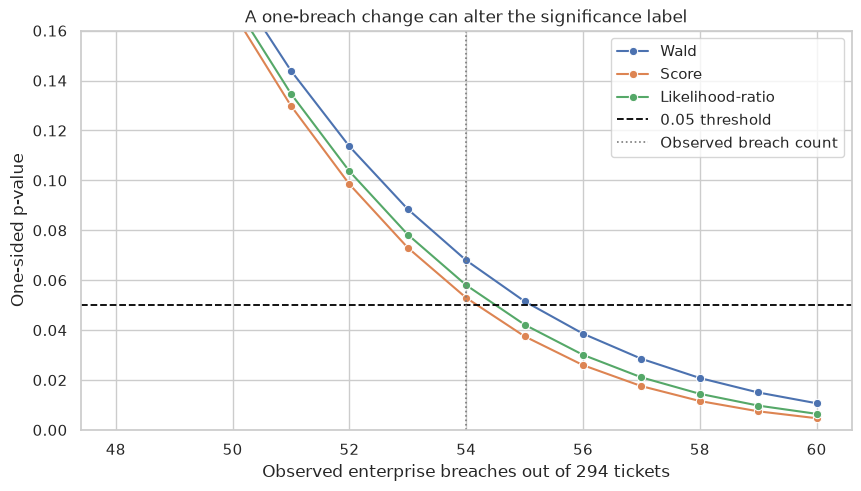

In [4]:
# Vary the observed breach count by a few cases to show how threshold labels can flip.
count_grid = np.arange(48, 61)
fragility_rows = []
for x in count_grid:
    tests = one_sample_binomial_tests(x, n_enterprise, p0=p0, alternative='greater')
    for _, row in tests.iterrows():
        fragility_rows.append(
            {
                'breaches': x,
                'test': row['test'],
                'p_value': row['p_value'],
            }
        )
fragility_df = pd.DataFrame(fragility_rows)

focus_counts = pd.DataFrame(
    [
        {'breaches': x, **{row['test']: row['p_value'] for _, row in one_sample_binomial_tests(x, n_enterprise, p0=p0, alternative='greater').iterrows()}}
        for x in [53, 54, 55]
    ]
)
for col in ['Wald', 'Score', 'Likelihood-ratio']:
    focus_counts[col] = focus_counts[col].map(lambda x: f"{x:0.4f}")
smart_display(focus_counts)

fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
sns.lineplot(data=fragility_df, x='breaches', y='p_value', hue='test', marker='o', ax=ax)
ax.axhline(0.05, color='black', linestyle='--', linewidth=1.3, label='0.05 threshold')
ax.axvline(x_enterprise, color='#7A7A7A', linestyle=':', linewidth=1.2, label='Observed breach count')
ax.set_title('A one-breach change can alter the significance label')
ax.set_xlabel('Observed enterprise breaches out of 294 tickets')
ax.set_ylabel('One-sided p-value')
ax.set_ylim(0, 0.16)
ax.legend(loc='upper right')
plt.show()

This figure is one of the cleanest arguments against threshold worship. Moving from 54 to 55 breaches does not create a new scientific reality. It creates a tiny change in the evidence. Yet for some test constructions that tiny change is enough to drop the p-value below 0.05.

This is why the right reading of the original sample is not "nothing is happening because p is above 0.05." The right reading is that the sample contains moderately suggestive evidence, but not enough precision to support a clean threshold-based declaration.

## 5. The P-value Itself Is Unstable Across Repeated Audits

The previous section changed the breach count by hand. Now we do the same idea honestly through repeated sampling.

Suppose the true enterprise breach rate were 17%, which is above the 15% threshold but only modestly so. If we repeatedly drew audits of about this size, how often would the resulting p-values fall below 0.05?

This matters because if p-values vary widely from sample to sample, then a single thresholded conclusion is often less stable than it appears (Halsey et al., 2015).

,test,median_p_value,share_below_0_05,10th_to_90th_percentile
0,Wald,0.178,20.7%,"[0.015, 0.629]"
1,Score,0.166,25.1%,"[0.008, 0.627]"
2,Likelihood-ratio,0.170,25.1%,"[0.010, 0.628]"


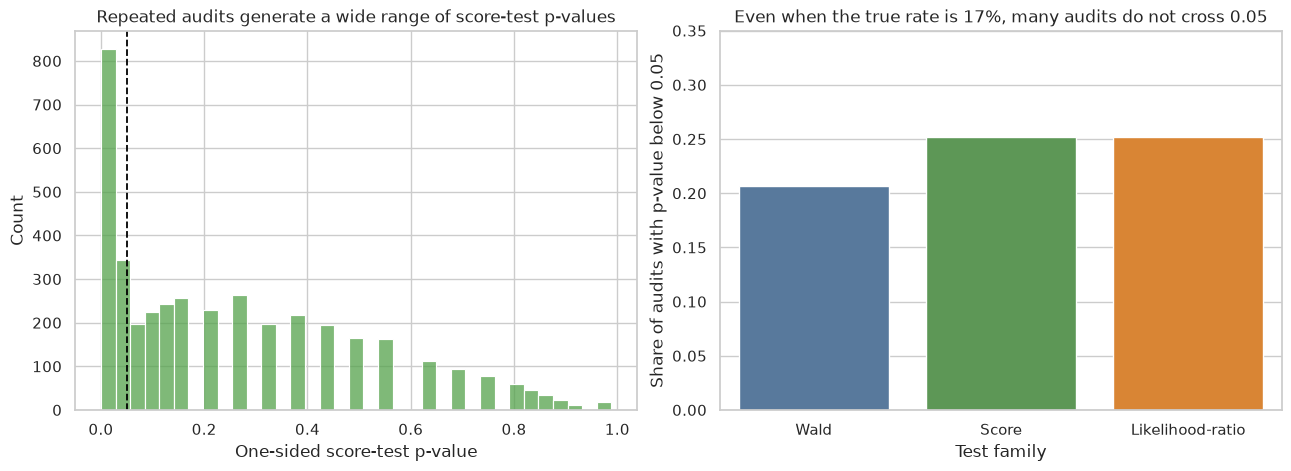

In [5]:
# Simulate repeated audits to show how p-values vary even when the true rate is fixed.
rng = np.random.default_rng(905)
true_rate = 0.17
n_sim = 300
reps = 4000
sim_counts = rng.binomial(n_sim, true_rate, size=reps)

wald_p = []
score_p = []
lr_p = []
for x in sim_counts:
    tests = one_sample_binomial_tests(int(x), n_sim, p0=p0, alternative='greater')
    p_values = dict(zip(tests['test'], tests['p_value']))
    wald_p.append(p_values['Wald'])
    score_p.append(p_values['Score'])
    lr_p.append(p_values['Likelihood-ratio'])

sim_summary = pd.DataFrame(
    [
        {
            'test': 'Wald',
            'median_p_value': f"{np.median(wald_p):0.3f}",
            'share_below_0_05': f"{100 * np.mean(np.array(wald_p) < 0.05):0.1f}%",
            '10th_to_90th_percentile': f"[{np.quantile(wald_p, 0.10):0.3f}, {np.quantile(wald_p, 0.90):0.3f}]",
        },
        {
            'test': 'Score',
            'median_p_value': f"{np.median(score_p):0.3f}",
            'share_below_0_05': f"{100 * np.mean(np.array(score_p) < 0.05):0.1f}%",
            '10th_to_90th_percentile': f"[{np.quantile(score_p, 0.10):0.3f}, {np.quantile(score_p, 0.90):0.3f}]",
        },
        {
            'test': 'Likelihood-ratio',
            'median_p_value': f"{np.median(lr_p):0.3f}",
            'share_below_0_05': f"{100 * np.mean(np.array(lr_p) < 0.05):0.1f}%",
            '10th_to_90th_percentile': f"[{np.quantile(lr_p, 0.10):0.3f}, {np.quantile(lr_p, 0.90):0.3f}]",
        },
    ]
)
smart_display(sim_summary)

score_df = pd.DataFrame({'score_p_value': score_p})
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.6), constrained_layout=True)

sns.histplot(score_df['score_p_value'], bins=35, color='#54A24B', ax=axes[0])
axes[0].axvline(0.05, color='black', linestyle='--', linewidth=1.3)
axes[0].set_title('Repeated audits generate a wide range of score-test p-values')
axes[0].set_xlabel('One-sided score-test p-value')
axes[0].set_ylabel('Count')

reject_df = pd.DataFrame(
    {
        'test': ['Wald', 'Score', 'Likelihood-ratio'],
        'reject_share': [np.mean(np.array(wald_p) < 0.05), np.mean(np.array(score_p) < 0.05), np.mean(np.array(lr_p) < 0.05)],
    }
)
sns.barplot(data=reject_df, x='test', y='reject_share', hue='test', palette=['#4C78A8', '#54A24B', '#F58518'], legend=False, ax=axes[1])
axes[1].set_ylim(0, 0.35)
axes[1].set_title('Even when the true rate is 17%, many audits do not cross 0.05')
axes[1].set_xlabel('Test family')
axes[1].set_ylabel('Share of audits with p-value below 0.05')

plt.show()

This simulation is the practical version of the "fickle p-value" argument.

Even when the true rate is above the null threshold, many audits still produce p-values above 0.05. A p-value above 0.05 can arise from noisy data, modest effects, and a testing threshold that compresses a continuous evidence process.

This is one reason why "non-significant" should never be interpreted as "no effect." A result can be non-significant and still be compatible with a real, policy-relevant departure from the null.

## 6. Small P-values Do Not Guarantee Practical Importance

The opposite mistake is also common: treating a small p-value as if it certifies that the effect is worth acting on.

To make that concrete, consider a very large internal pilot of a workflow-assistance script. Suppose the pilot changes average resolution time by only about half a minute, while leadership would require at least a **3-minute improvement** before rolling the system out broadly.

A very large sample can make a tiny effect statistically detectable without making it operationally meaningful.

,quantity,value,interpretation
0,Observed mean difference (assist - baseline),-0.46 minutes,Negative values mean faster average resolution under the workflow-assist pilot.
1,Two-sided p-value,0.003105,The pilot produces a statistically detectable difference because the sample is very large.
2,95% confidence interval,"[-0.77, -0.16] minutes","The interval is narrow and excludes zero, but it remains far from the 3-minute business target."
3,Business rollout threshold,-3.0 minutes,Leadership would need a much larger time reduction before broad deployment would make sense.


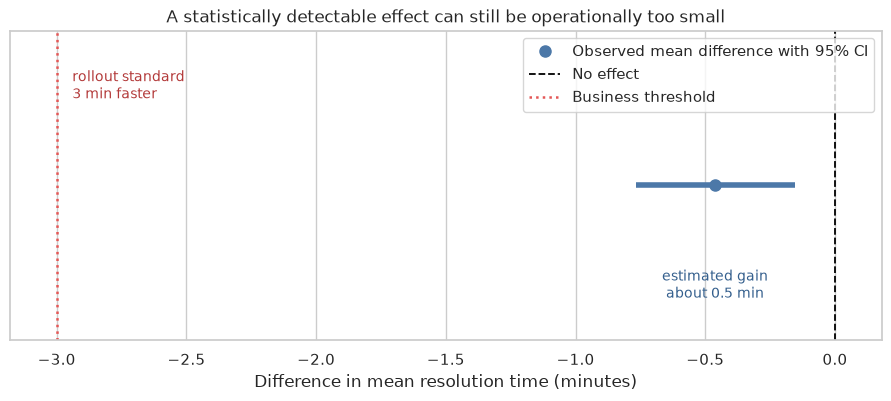

In [6]:
# Compare a statistically detectable mean difference with the larger business rollout threshold.
large_population = make_support_population(n=120_000, seed=311, sla_minutes=sla_minutes)
baseline = large_population.sample(n=30_000, random_state=77)['resolution_minutes'].to_numpy()
workflow_assist = large_population.sample(n=30_000, random_state=88)['resolution_minutes'].to_numpy() - 0.45

mean_diff, mean_diff_se, mean_diff_z, mean_diff_p, mean_diff_ci = two_sample_mean_test(workflow_assist, baseline)
practical_threshold = -3.0

practical_table = pd.DataFrame(
    [
        {
            'quantity': 'Observed mean difference (assist - baseline)',
            'value': f"{mean_diff:0.2f} minutes",
            'interpretation': 'Negative values mean faster average resolution under the workflow-assist pilot.',
        },
        {
            'quantity': 'Two-sided p-value',
            'value': f"{mean_diff_p:0.6f}",
            'interpretation': 'The pilot produces a statistically detectable difference because the sample is very large.',
        },
        {
            'quantity': '95% confidence interval',
            'value': f"[{mean_diff_ci[0]:0.2f}, {mean_diff_ci[1]:0.2f}] minutes",
            'interpretation': 'The interval is narrow and excludes zero, but it remains far from the 3-minute business target.',
        },
        {
            'quantity': 'Business rollout threshold',
            'value': f"{practical_threshold:0.1f} minutes",
            'interpretation': 'Leadership would need a much larger time reduction before broad deployment would make sense.',
        },
    ]
)
smart_display(practical_table)

fig, ax = plt.subplots(figsize=(8.8, 3.9), constrained_layout=True)
ax.hlines(0, mean_diff_ci[0], mean_diff_ci[1], color='#4C78A8', linewidth=4)
ax.plot(mean_diff, 0, 'o', color='#4C78A8', markersize=8, label='Observed mean difference with 95% CI')
ax.axvline(0, color='black', linestyle='--', linewidth=1.3, label='No effect')
ax.axvline(practical_threshold, color='#E45756', linestyle=':', linewidth=1.8, label='Business threshold')
ax.text(mean_diff, -0.15, 'estimated gain\nabout 0.5 min', color='#345F8D', ha='center', va='top', fontsize=10)
ax.text(practical_threshold + 0.06, 0.18, 'rollout standard\n3 min faster', color='#B33A3A', ha='left', va='center', fontsize=10)
ax.set_xlim(practical_threshold - 0.18, 0.18)
ax.set_ylim(-0.28, 0.28)
ax.set_yticks([])
ax.set_xlabel('Difference in mean resolution time (minutes)')
ax.set_title('A statistically detectable effect can still be operationally too small')
ax.legend(loc='upper right', frameon=True)
plt.show()

This is the mirror image of the earlier threshold example.

Here the p-value is very small, and the interval excludes zero comfortably. So the data do support the claim that the workflow-assist pilot changed average resolution time. But the estimated improvement is far smaller than the 3-minute gain required for deployment.

That means the right conclusion is not "the pilot worked, therefore ship it." The right conclusion is that the pilot produced a measurable effect that is too small to justify the operational commitment. Statistical detectability and practical usefulness are different questions.

## 7. Decision Memo: Testing as One Input, Not the Entire Decision Rule

We now return to the enterprise-threshold problem. The strongest memo will not simply recite a p-value. It will integrate the estimate, the test results, and the interval evidence into one clear operational recommendation.

In [7]:
# Combine test results, estimates, and interval evidence in a decision memo.
enterprise_test_values = one_sample_binomial_tests(x_enterprise, n_enterprise, p0=p0, alternative='greater')
wald_p = float(enterprise_test_values.query("test == 'Wald'")['p_value'].iloc[0])
score_p = float(enterprise_test_values.query("test == 'Score'")['p_value'].iloc[0])
lr_p = float(enterprise_test_values.query("test == 'Likelihood-ratio'")['p_value'].iloc[0])

if all(p < 0.05 for p in [wald_p, score_p, lr_p]) and profile_interval[0] > p0:
    recommendation = 'Do not present the premium promise as meeting the 15% threshold; the evidence strongly supports a breach rate above target.'
elif p_hat_enterprise < p0:
    recommendation = 'Continue collecting evidence before making a stronger public claim about premium service reliability.'
else:
    recommendation = 'Do not certify the enterprise promise yet; continue process improvement and additional auditing.'

memo = (
    f"### Decision Memo\n\n"
    f"**Recommendation:** {recommendation}\n\n"
    f"**Observed enterprise breach estimate:** **{100 * p_hat_enterprise:0.2f}%** based on **{x_enterprise}** breaches among **{n_enterprise}** audited enterprise tickets.\n\n"
    f"**Test evidence for the question $H_0: p = 15\\%$ versus $H_1: p > 15\\%$:**\n\n"
    f"- Wald p-value: **{wald_p:0.4f}**\n"
    f"- Score p-value: **{score_p:0.4f}**\n"
    f"- Likelihood-ratio p-value: **{lr_p:0.4f}**\n"
    f"- Approximate 95% profile-likelihood interval: **[{100 * profile_interval[0]:0.2f}%, {100 * profile_interval[1]:0.2f}%]**\n\n"
    f"**Interpretation:** None of the three tests crosses below 0.05, but all of them are close enough that the result should be interpreted as moderately suggestive with caution about declaring no problem. "
    f"The point estimate remains above the business threshold, and the compatible interval still includes values above 15%. The correct operational stance is therefore caution: do not market the premium promise as established, and do not pretend that a p-value just above 0.05 means the threshold is safe."
)

display(Markdown(memo))

### Decision Memo

**Recommendation:** Do not certify the enterprise promise yet; continue process improvement and additional auditing.

**Observed enterprise breach estimate:** **18.37%** based on **54** breaches among **294** audited enterprise tickets.

**Test evidence for the question $H_0: p = 15\%$ versus $H_1: p > 15\%$:**

- Wald p-value: **0.0680**
- Score p-value: **0.0529**
- Likelihood-ratio p-value: **0.0580**
- Approximate 95% profile-likelihood interval: **[14.23%, 23.06%]**

**Interpretation:** None of the three tests crosses below 0.05, but all of them are close enough that the result should be interpreted as moderately suggestive with caution about declaring no problem. The point estimate remains above the business threshold, and the compatible interval still includes values above 15%. The correct operational stance is therefore caution: do not market the premium promise as established, and do not pretend that a p-value just above 0.05 means the threshold is safe.

<!-- real-data-companion-course01 -->
## Real-Data Companion: Testing a Policy-Relevant Utilization Contrast

RAND HIE gives a real setting where a test statistic has policy meaning. The simplified comparison is between records assigned to free care and records assigned to cost sharing, using outpatient physician visits (`mdvis`) as the utilization outcome.

The unit is a person-period record. The treatment-like contrast is based on insurance generosity, with `lncoins == 0` used to identify free care in the statsmodels table. The statistical question is whether the utilization difference is large enough, stable enough, and directionally clear enough to support a substantive statement.

The experiment is designed to move beyond a p-value. It reports the direction, magnitude, uncertainty, and practical scale of the contrast. It does not settle every RAND HIE policy question, because a full policy analysis would include plan details, costs, health outcomes, and subgroup effects. Here the real dataset anchors the lesson that tests are useful only after the estimand and decision relevance are explicit.

Data source: [RAND Health Insurance Experiment in statsmodels](https://www.statsmodels.org/stable/datasets/generated/randhie.html).

,quantity,value
0,"Mean visits, free care",3.123600
1,"Mean visits, cost sharing",2.545600
2,Difference in means,0.577900
3,Welch t-test p-value,0.000000
4,Practical threshold used for discussion,0.250000
5,Difference above practical threshold,0.327900


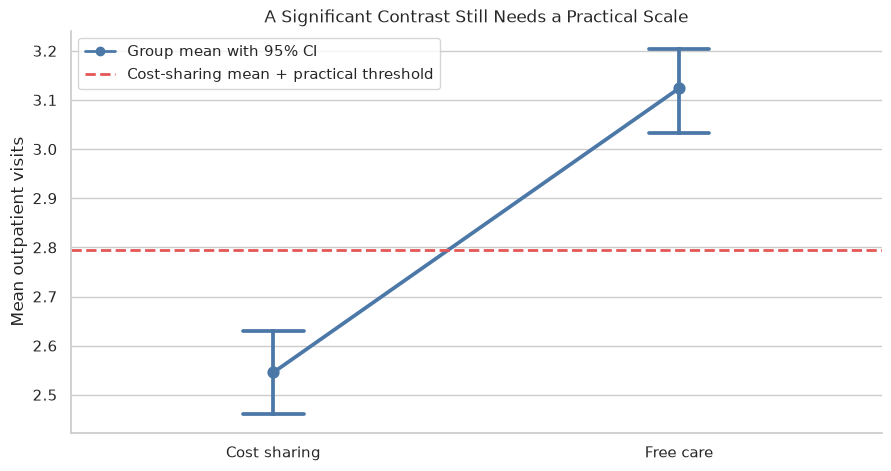

In [8]:
# real-data-companion-course01
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D
from scipy import stats


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio root so shared notebook helpers import reliably.
    
    Parameters:
        start: Starting path for the upward project-root search.
    
    Returns:
        A `Path` pointing to the nearest portfolio root that contains `notebooks/_shared`; if no such parent is found, the original starting path is returned.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.display import smart_display
from notebooks._shared.real_data import load_statsmodels_randhie, optional_data_note

RUN_REAL_DATA_COMPANION = True

if RUN_REAL_DATA_COMPANION:
    rand_hie = load_statsmodels_randhie().copy()
    rand_hie["coinsurance"] = np.expm1(rand_hie["lncoins"]).round().clip(0, 100)
    free = rand_hie.loc[rand_hie["coinsurance"].eq(0), "mdvis"]
    cost = rand_hie.loc[rand_hie["coinsurance"].gt(0), "mdvis"]
    observed_diff = free.mean() - cost.mean()
    test = stats.ttest_ind(free, cost, equal_var=False)

    threshold = 0.25
    result_table = pd.DataFrame(
        [
            {"quantity": "Mean visits, free care", "value": free.mean()},
            {"quantity": "Mean visits, cost sharing", "value": cost.mean()},
            {"quantity": "Difference in means", "value": observed_diff},
            {"quantity": "Welch t-test p-value", "value": test.pvalue},
            {"quantity": "Practical threshold used for discussion", "value": threshold},
            {"quantity": "Difference above practical threshold", "value": observed_diff - threshold},
        ]
    )
    smart_display(result_table.round(4))

    fig, ax = plt.subplots(figsize=(8.8, 4.6), constrained_layout=True)
    plot_df = rand_hie.assign(plan_group=np.where(rand_hie["coinsurance"].eq(0), "Free care", "Cost sharing"))
    sns.pointplot(
        data=plot_df,
        x="plan_group",
        y="mdvis",
        order=["Cost sharing", "Free care"],
        errorbar=("ci", 95),
        capsize=0.15,
        ax=ax,
        color="#4C78A8",
    )
    ax.axhline(cost.mean() + threshold, color="#E45756", linestyle="--", linewidth=2)
    legend_handles = [
        Line2D([0], [0], color="#4C78A8", marker="o", linewidth=2, label="Group mean with 95% CI"),
        Line2D([0], [0], color="#E45756", linestyle="--", linewidth=2, label="Cost-sharing mean + practical threshold"),
    ]
    ax.set_title("A Significant Contrast Still Needs a Practical Scale")
    ax.set_xlabel("")
    ax.set_ylabel("Mean outpatient visits")
    ax.legend(handles=legend_handles, frameon=True, loc="upper left")
    sns.despine(fig=fig)
    plt.show()
else:
    optional_data_note(
        "RAND Health Insurance Experiment",
        "https://www.statsmodels.org/stable/datasets/generated/randhie.html",
        "RUN_REAL_DATA_COMPANION",
    )

<!-- real-data-companion-course01 -->
This companion disciplines p-value interpretation with a real policy contrast. The free-care group has more outpatient visits than the cost-sharing group, and the Welch test is extremely small on the p-value scale. That establishes statistical evidence for a utilization difference, but it does not by itself tell us whether the additional visits improved health, increased unnecessary care, changed costs acceptably, or affected groups equitably.

The practical threshold line in the plot adds the missing decision scale. In this example, the mean difference is larger than the illustrative 0.25-visit threshold, so the result is both statistically clear and practically visible under that chosen benchmark. In a real policy memo, that benchmark would need to be justified before the p-value could support a recommendation.

## 8. What to Remember

1. A p-value measures how surprising the observed statistic would be under a null model; it is not the probability that the null is true.
2. Wald, score, and likelihood-ratio tests often agree in large samples, but near decision thresholds their p-values can differ enough to matter.
3. A hard significance cutoff can convert a smooth evidence change into an abrupt labeling change.
4. Repeated samples can generate widely varying p-values even when the true effect is fixed.
5. A non-significant result does not imply no effect, especially when the effect is modest and the sample is only moderately informative.
6. A significant result does not imply practical importance, especially in very large samples.
7. Better testing practice combines p-values with effect sizes, intervals, and explicit decision thresholds so no single number carries every inferential job.

The next notebook stays with testing logic but moves to permutation, randomization, and exact inference, where we can sometimes avoid or reduce reliance on large-sample approximations altogether.

## References

- Greenland, S., Senn, S. J., Rothman, K. J., Carlin, J. B., Poole, C., Goodman, S. N., & Altman, D. G. (2016). *Statistical tests, P values, confidence intervals, and power: a guide to misinterpretations*. *European Journal of Epidemiology, 31*(4), 337-350. [https://doi.org/10.1007/s10654-016-0149-3](https://doi.org/10.1007/s10654-016-0149-3)
- Halsey, L. G., Curran-Everett, D., Vowler, S. L., & Drummond, G. B. (2015). *The fickle P value generates irreproducible results*. *Nature Methods, 12*(3), 179-185. [https://doi.org/10.1038/nmeth.3288](https://doi.org/10.1038/nmeth.3288)
- Wasserstein, R. L., Schirm, A. L., & Lazar, N. A. (2019). *Moving to a World Beyond "p < 0.05"*. *The American Statistician, 73*(sup1), 1-19. [https://doi.org/10.1080/00031305.2019.1583913](https://doi.org/10.1080/00031305.2019.1583913)
- Wilks, S. S. (1938). *The large-sample distribution of the likelihood ratio for testing composite hypotheses*. *The Annals of Mathematical Statistics, 9*(1), 60-62. [https://doi.org/10.1214/aoms/1177732360](https://doi.org/10.1214/aoms/1177732360)